In [2]:
import pandas as pd
import numpy as np
import os

# 1. Load raw data


df1 = pd.read_csv("data/raw/houses_data_eng.csv")
df2 = pd.read_csv("data/raw/morocco_houses_dataset.csv")

print("df1:", df1.shape)
print("df2:", df2.shape)
# ---------- SOURCE 1: extract type & city from address ----------
df1 = df1.rename(columns=lambda c: str(c).strip())
# Clean column names just in case
df1.columns = [c.strip() for c in df1.columns]

m = df1["address"].str.extract(r"^(?P<type>.+?) à vendre (?P<city>.+?) - (?P<quarter>.+)$")
df1["property_type"] = m["type"].str.strip().str.lower()
df1["city"] = m["city"].str.strip().str.lower()
df1 = df1.dropna(subset=["city"])
df1 = df1.rename(columns={
    "new_price": "price",
    "surface": "area",
    "chambres": "bedrooms",
    "salles de bains": "bathrooms",
})

# ---------- SOURCE 2: SALES ONLY + kill leakage ----------
df2 = df2[df2["transaction"] == "vente"].copy()
df2 = df2.drop(columns=["price_per_sqm", "reference"], errors="ignore")
df2 = df2.rename(columns={"type": "property_type", "surface": "area"})

# ---------- Force ONE contract schema ----------
keep = ["city", "property_type", "price", "area", "rooms", "bedrooms", "bathrooms", "floor"]

def contract(df):
    out = df[[c for c in keep if c in df.columns]].copy()
    for c in keep:
        if c not in out.columns:
            out[c] = np.nan
    return out[keep]

df = pd.concat([contract(df1), contract(df2)], ignore_index=True)
df = df[df["property_type"] != "bureau"]
df["property_type"] = df["property_type"].str.strip().str.lower()

print("Combined:", df.shape)

# Save to processed
os.makedirs("../data/processed", exist_ok=True)
df.to_csv("../data/processed/houses_combined.csv", index=False)

df1: (4675, 15)
df2: (10000, 16)
Combined: (11478, 8)


In [4]:
import pandas as pd
import numpy as np

df1 = pd.read_csv("data/raw/houses_data_eng.csv")
df2 = pd.read_csv("data/raw/morocco_houses_dataset.csv")
print("df1:", df1.shape, "| df2:", df2.shape)

# ---------- SOURCE 1 (messy): cut address into pieces ----------
df1.columns = [str(c).strip() for c in df1.columns]
m = df1["address"].str.extract(r"^(?P<type>.+?) à vendre (?P<city>.+?) - (?P<neighborhood>.+)$")
df1["property_type"] = m["type"].str.strip().str.lower()
df1["city"] = m["city"].str.strip().str.lower()
df1["neighborhood"] = m["neighborhood"].str.strip().str.lower()
df1 = df1.dropna(subset=["city"])
if "ascenseur" in df1.columns:
    df1["amenities_count"] = (df1["ascenseur"].str.strip().str.lower() == "yes").astype(float)
df1 = df1.rename(columns={
    "new_price": "price", "surface": "area",
    "chambres": "rooms", "salles de bains": "bathrooms",
})

# ---------- SOURCE 2 (clean): kill the 3 traps ----------
df2 = df2[df2["transaction"] == "vente"].copy()                      # trap 1
df2 = df2.drop(columns=["price_per_sqm", "reference"], errors="ignore")  # trap 2+3
df2["amenities_count"] = df2["amenities"].fillna("").str.split(",").str.len()
df2 = df2.rename(columns={"type": "property_type", "surface": "area"})

# ---------- ONE contract ----------
keep = ["city", "neighborhood", "property_type", "condition", "age",
        "price", "area", "rooms", "bathrooms", "floor", "amenities_count"]

def contract(df):
    out = df[[c for c in keep if c in df.columns]].copy()
    for c in keep:
        if c not in out.columns:
            out[c] = np.nan
    return out[keep]

df = pd.concat([contract(df1), contract(df2)], ignore_index=True)
df = df[~df["property_type"].isin(["bureau", "nan", ""])]

print("Combined:", df.shape)
df.to_csv("../data/processed/houses_combined.csv", index=False)

df1: (4675, 15) | df2: (10000, 16)
Combined: (11478, 11)


Matplotlib is building the font cache; this may take a moment.


Found data at: /home/mhd/projects/DarPrice/data/raw/morocco_houses_dataset.csv
Raw shape: (10000, 16)
Clean shape: (6990, 13)

===== REPORT FOR SENIOR =====
1) Raw rows -> Clean rows: 6990 kept
2) #1 City by median price: casablanca (2,566,440 MAD)
3) Overall median price: 2,272,168 MAD
4) Top correlation with price: area (0.92)



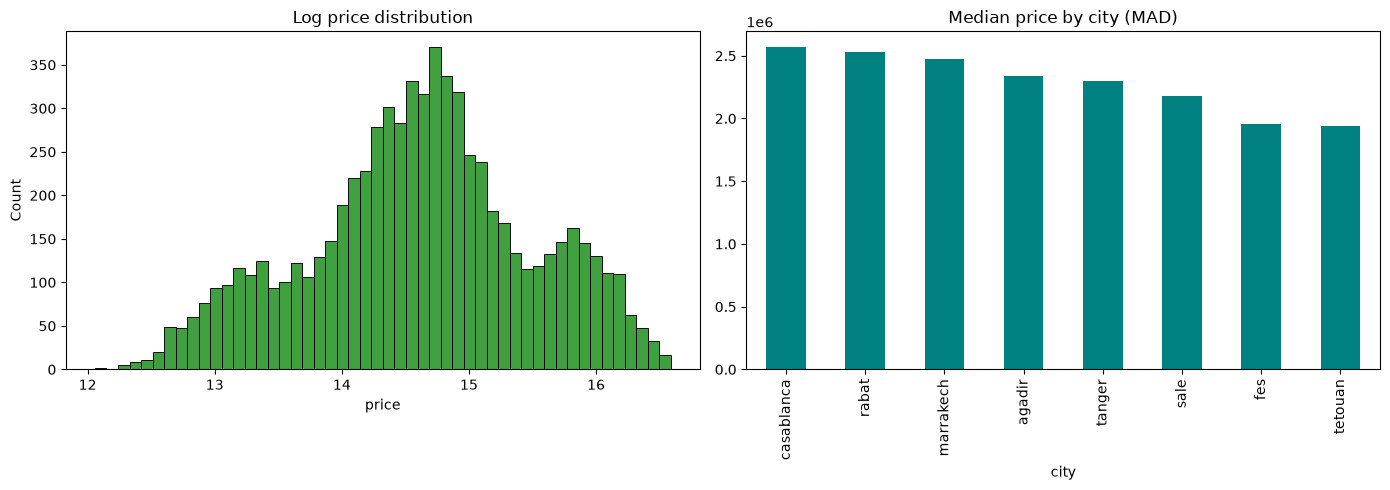

In [2]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# 1. AUTO-FIND THE DATA (No more path errors)
cwd = Path.cwd()
ROOT = cwd if (cwd / "data").exists() else cwd.parent
csv_file = ROOT / "data/raw/morocco_houses_dataset.csv"

if not csv_file.exists():
    print(f"ERROR: I cannot find {csv_file}. Make sure it is there!")
else:
    print(f"Found data at: {csv_file}")
    df = pd.read_csv(csv_file)
    print(f"Raw shape: {df.shape}")

    # 2. TRAPS & CLEANING
    df = df[df['transaction'] == 'vente'].copy()           # Trap 1: Sales only
    df = df.drop(columns=['price_per_sqm', 'reference', 'description', 'listing_date'], errors='ignore') # Trap 2: Leakage + noise
    df = df.rename(columns={'type': 'property_type', 'surface': 'area'})
    
    # Create a safe numeric feature
    df['amenities_count'] = df['amenities'].fillna('').str.split(',').str.len()

    # Force numbers
    for col in ['price', 'area', 'rooms', 'bathrooms', 'floor', 'age']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Drop garbage
    df = df.drop_duplicates()
    df = df.dropna(subset=['price', 'area'])
    df = df[(df['price'] > 50000) & (df['area'] >= 10)] # No 500 MAD houses
    
    # Remove extreme outliers (Moroccan market reality)
    ppm2 = df['price'] / df['area']
    df = df[(ppm2 > 2000) & (ppm2 < 80000)] 
    
    # Clean text
    for col in ['city', 'neighborhood', 'property_type', 'condition']:
        df[col] = df[col].astype(str).str.strip().str.lower()

    print(f"Clean shape: {df.shape}")

    # 3. THE REPORT
    city_med = df.groupby('city')['price'].median().sort_values(ascending=False)
    num_corr = df[['area', 'rooms', 'bathrooms', 'floor', 'age', 'amenities_count', 'price']].corr()['price'].drop('price').sort_values(ascending=False)

    print("\n===== REPORT FOR SENIOR =====")
    print(f"1) Raw rows -> Clean rows: {df.shape[0]} kept")
    print(f"2) #1 City by median price: {city_med.index[0]} ({city_med.iloc[0]:,.0f} MAD)")
    print(f"3) Overall median price: {df['price'].median():,.0f} MAD")
    print(f"4) Top correlation with price: {num_corr.index[0]} ({num_corr.iloc[0]:.2f})")
    print("==============================\n")

    # 4. PLOTS
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(np.log1p(df['price']), bins=50, ax=axes[0], color='green').set_title('Log price distribution')
    city_med.head(8).plot(kind='bar', ax=axes[1], color='teal')
    axes[1].set_title('Median price by city (MAD)')
    plt.tight_layout()
    plt.show()

In [4]:
from sklearn.model_selection import train_test_split


In [5]:
y = df["price"]
X = df.drop(columns=["price"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
baseline_pred = y_train.mean()
baseline_mae = (y_test - baseline_pred).abs().mean()

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# which columns are numbers, which are text?
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
print("num:", num_cols)
print("cat:", cat_cols)

# LEFT belt: numbers
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# RIGHT belt: text
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
])

# the full factory: preprocess, then linear recipe
model = Pipeline([
    ("pre", preprocessor),
    ("reg", LinearRegression()),
])

# STUDY on train only
model.fit(X_train, y_train)

# EXAM on test
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"LinearRegression MAE: {mae:,.0f} MAD")
print(f"R2: {r2:.3f}")

/tmp/ipykernel_1114058/1351382719.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns.tolist()


num: ['area', 'rooms', 'bathrooms', 'floor', 'age', 'amenities_count']
cat: ['property_type', 'transaction', 'city', 'neighborhood', 'condition', 'amenities']
LinearRegression MAE: 766,054 MAD
R2: 0.866


In [10]:
from sklearn.ensemble import RandomForestRegressor

model2 = Pipeline([
    ("pre", preprocessor),          # same sorting table + cleaners + lightbulbs
    ("reg", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
])

model2.fit(X_train, y_train)        # 100 agents study (takes ~1 minute, normal)
y_pred2 = model2.predict(X_test)

mae2 = mean_absolute_error(y_test, y_pred2)
r22 = r2_score(y_test, y_pred2)

print(f"RandomForest MAE: {mae2:,.0f} MAD")
print(f"RandomForest R2: {r22:.3f}")

RandomForest MAE: 585,105 MAD
RandomForest R2: 0.902


--- TOP 10 CLUES THE MODEL USED ---
                   Clue  Importance
0                  area    0.865633
11  property_type_villa    0.015886
4                   age    0.010772
14      city_casablanca    0.009337
17       city_marrakech    0.008782
9    property_type_riad    0.007833
1                 rooms    0.006185
2             bathrooms    0.005847
5       amenities_count    0.005399
20           city_rabat    0.002767


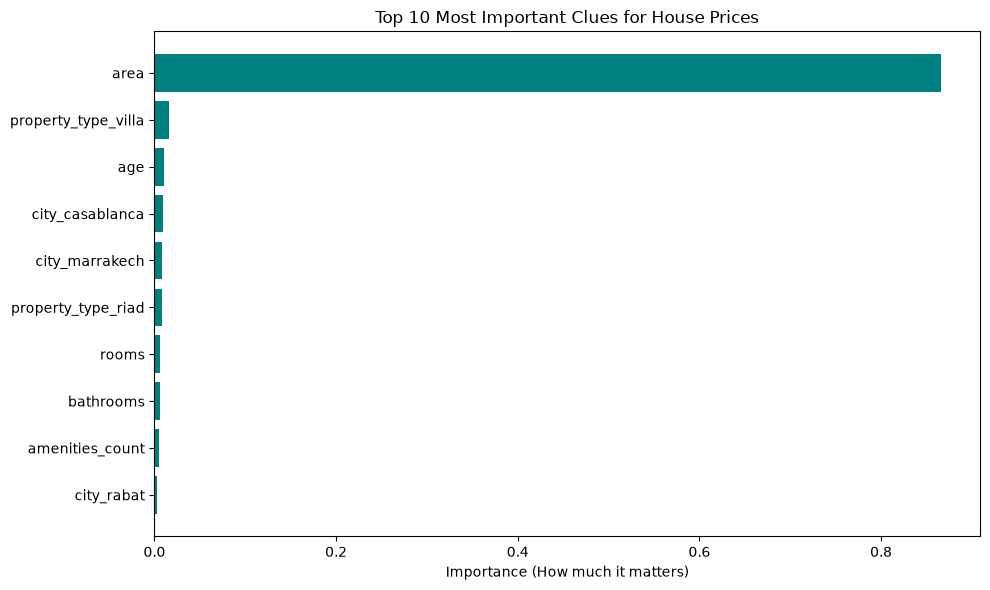

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Get the preprocessor and the forest from your pipeline (model2)
preprocessor = model2.named_steps['pre']
forest = model2.named_steps['reg']

# 2. Get the names of the numeric columns (they stay the same)
num_names = num_cols

# 3. Get the names of the new lightbulb columns created by OneHotEncoder
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']
cat_names = cat_encoder.get_feature_names_out(cat_cols)

# 4. Put all names together in one big list
all_names = list(num_names) + list(cat_names)

# 5. Get the importance scores from the Forest (adds up to 1.0)
importances = forest.feature_importances_

# 6. Make a nice table and sort it from biggest to smallest
importance_df = pd.DataFrame({
    'Clue': all_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 7. Print the Top 10
print("--- TOP 10 CLUES THE MODEL USED ---")
print(importance_df.head(10))

# 8. Draw a beautiful chart
plt.figure(figsize=(10, 6))
top10 = importance_df.head(10)
plt.barh(top10['Clue'][::-1], top10['Importance'][::-1], color='teal')
plt.title("Top 10 Most Important Clues for House Prices")
plt.xlabel("Importance (How much it matters)")
plt.tight_layout()
plt.show()

In [12]:
import joblib

(ROOT / "models").mkdir(exist_ok=True)   # create the folder if missing
joblib.dump(model2, ROOT / "models/darprice_randomforest.joblib")

# prove a stranger can use it
loaded = joblib.load(ROOT / "models/darprice_randomforest.joblib")
print("Real price: ", y_test.head(1).values[0])
print("Model guess:", round(loaded.predict(X_test.head(1))[0]))

Real price:  1773678
Model guess: 1513162


In [2]:
# Caesar cipher.
text = input("Enter your message: ")
cipher = ''
for char in text:
    if not char.isalpha():
        continue
    char = char.upper()
    code = ord(char) + 1
    if code > ord('Z'):
        code = ord('A')
    cipher += chr(code)

print(cipher)

NPIBNFE
